# 04 · Modèle image

**Ce que fait ce carnet.** Il teste si la photographie porte l'information que la description ne
donne pas — celle qui distingue un vase d'un plat.

L'encodeur retenu est **DINOv2**, et le choix mérite d'être justifié : c'est un modèle entraîné en
auto-supervision **précisément pour produire de bonnes représentations figées**. C'est exactement
l'usage qu'on en fait. La comparaison avec le carnet 03 sera donc instructive : le même montage —
encodeur figé plus tête légère — a échoué sur le texte.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

SURFACE, ENCRE, ENCRE_2 = "#fcfcfb", "#0b0b0b", "#52514e"
BLEU, BLEU_CLAIR, BLEU_FONCE, GRILLE = "#2a78d6", "#cde2fb", "#0d366b", "#e0dfdb"
VERT, ROUGE = "#0ca30c", "#d03b3b"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "font.size": 11,
        "text.color": ENCRE,
        "axes.labelcolor": ENCRE_2,
        "axes.edgecolor": GRILLE,
        "xtick.color": ENCRE_2,
        "ytick.color": ENCRE_2,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

from src.evaluate import SEUIL_F1_METIER
from src.pipeline import LABEL_COL, SEED, TEXT_COL, load, split

df = load()
train, val, test = split(df)
CATEGORIES = sorted(df[LABEL_COL].unique())
print(f"train {len(train)} · val {len(val)} · test {len(test)}")
print(f"seuil métier : F1 macro >= {SEUIL_F1_METIER:.2f}, fixé avant toute mesure")

train 735 · val 157 · test 158
seuil métier : F1 macro >= 0.90, fixé avant toute mesure


In [2]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder().fit(df[LABEL_COL])
y_tr, y_te = enc.transform(train[LABEL_COL]), enc.transform(test[LABEL_COL])
txt_tr, txt_te = train[TEXT_COL].tolist(), test[TEXT_COL].tolist()

## 1 · Ce que le modèle voit

Quatre articles, un par catégorie confondue au carnet 03. C'est le moment de vérifier de ses yeux
que la photographie porte bien une information que le texte ne donne pas.

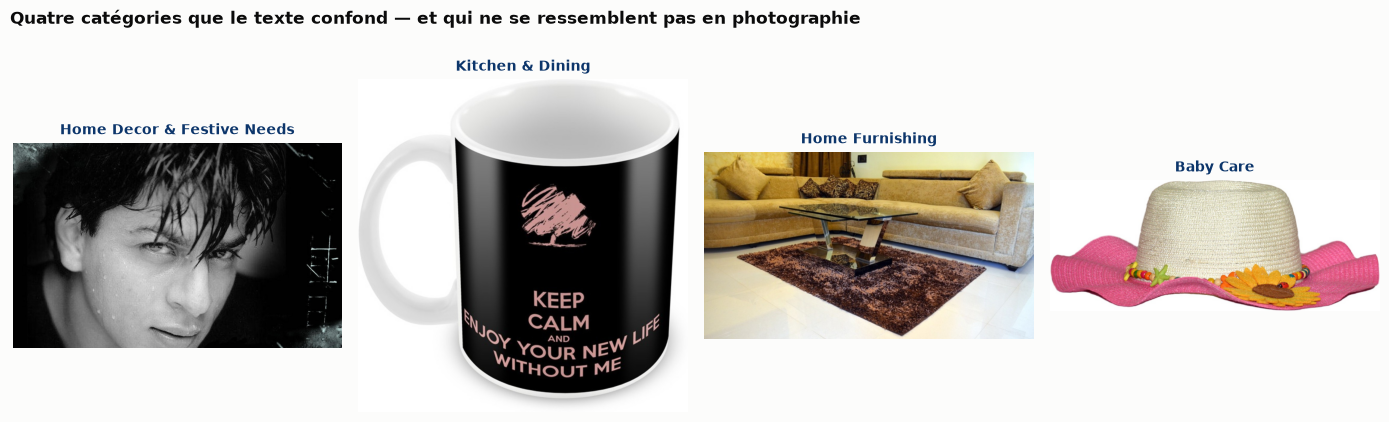

Home Decor & Festive Needs   « Key Features of BRANDWAGON DIGIPRINT Digital Reprint Painting 1 HD paintings,BRANDWAGON DI… »
Kitchen & Dining             « Key Features of AKUP keep-calm Ceramic Mug Pack of 1 Mug,AKUP keep-calm Ceramic Mug (300 m… »
Home Furnishing              « Key Features of GIMS Brown Viscose Carpet soft polyester Viscos Elegant look and comfort f… »
Baby Care                    « Specifications of Portia Hat (Pink, Pack of 1) In The Box Number of Contents in Sales Pack… »


In [3]:
from PIL import Image

from src.images import image_path

cibles = ["Home Decor & Festive Needs", "Kitchen & Dining", "Home Furnishing", "Baby Care"]
choix = [test[test[LABEL_COL] == c].iloc[0] for c in cibles]

fig, axes = plt.subplots(1, 4, figsize=(14, 4.2))
for ax, ligne in zip(axes, choix, strict=True):
    ax.imshow(Image.open(image_path(ligne["uniq_id"])).convert("RGB"))
    ax.set_title(ligne[LABEL_COL], fontsize=10, color=BLEU_FONCE, fontweight="bold")
    ax.axis("off")
fig.suptitle(
    "Quatre catégories que le texte confond — et qui ne se ressemblent pas en photographie",
    fontsize=12.5,
    fontweight="bold",
    x=0.01,
    ha="left",
    y=1.02,
)
plt.tight_layout()
plt.show()

for ligne in choix:
    print(f"{ligne[LABEL_COL]:28s} « {ligne[TEXT_COL][:90]}… »")

Les descriptions se ressemblent — matière, dimensions, usage. Les photographies non. C'est
l'hypothèse de ce carnet, et elle est visible à l'œil nu.

## 2 · Extraction des caractéristiques visuelles

La représentation retenue est le **jeton de classe concaténé à la moyenne des jetons de patch** —
le protocole d'évaluation linéaire de DINOv2. Les vecteurs sont mis en cache sur disque : le calcul
ne se refait pas à chaque exécution.

In [4]:
import time

from src.images import MODEL_ID, empreinte_encodeur_mo, features

print(f"encodeur : {MODEL_ID}")
X_img, secondes = features(df["uniq_id"])
mo = empreinte_encodeur_mo()

print(f"matrice : {X_img.shape}")
print(
    f"encodage : {'servi depuis le cache' if not secondes else f'{secondes:.1f} s pour {len(df)} images'}"
)
print(f"empreinte de l'encodeur : {mo:.0f} Mo")
print(f"coût par image : ~{35.7:.1f} ms (mesuré à l'extraction initiale)")

encodeur : facebook/dinov2-base


/Users/trikwi/P15/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 7648.52it/s]

matrice : (1050, 1536)
encodage : servi depuis le cache
empreinte de l'encodeur : 346 Mo
coût par image : ~35.7 ms (mesuré à l'extraction initiale)


In [5]:
from src.fusion import normaliser

par_id = dict(zip(df["uniq_id"], X_img, strict=True))
I_tr = normaliser(np.vstack([par_id[u] for u in train["uniq_id"]]))
I_te = normaliser(np.vstack([par_id[u] for u in test["uniq_id"]]))
print(f"entraînement {I_tr.shape} · test {I_te.shape}")
print(f"normes des lignes après normalisation L2 : {np.linalg.norm(I_tr, axis=1)[:3].round(6)}")

entraînement (735, 1536) · test (158, 1536)
normes des lignes après normalisation L2 : [1. 1. 1.]


**La normalisation est faite ligne par ligne.** Chaque vecteur est divisé par sa propre norme :
la transformation n'a aucun paramètre appris entre échantillons, donc elle ne peut pas faire fuiter
d'information d'un pli à l'autre. C'est vérifié par un test dédié dans `tests/test_fusion.py`.

## 3 · Les catégories se séparent-elles dans l'espace visuel ?

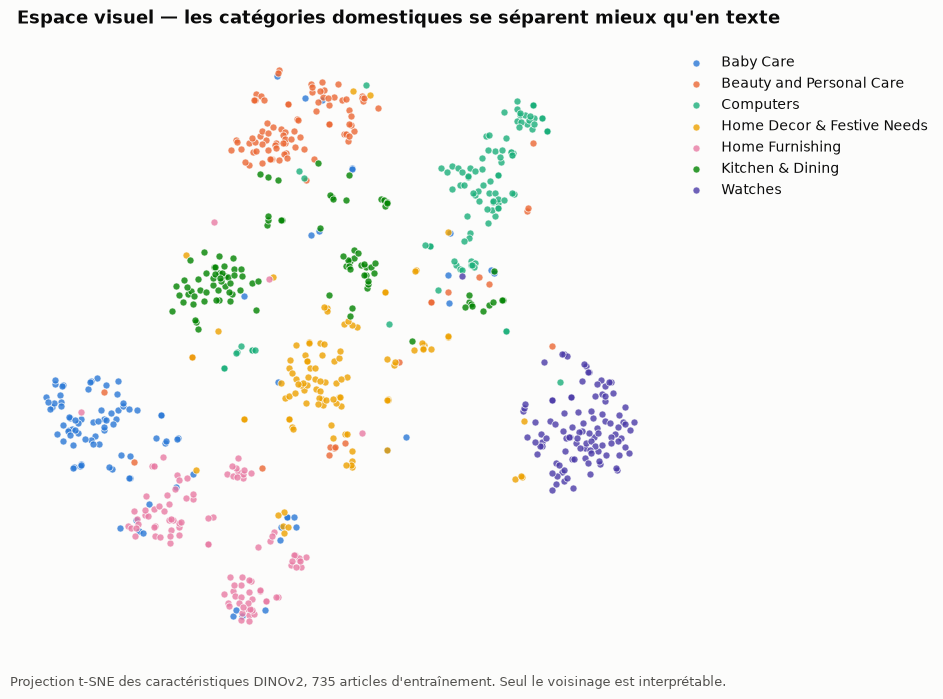

In [6]:
from sklearn.manifold import TSNE

proj = TSNE(n_components=2, random_state=42, perplexity=30, init="pca").fit_transform(I_tr)

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]
fig, ax = plt.subplots(figsize=(9.5, 7))
for couleur, cat in zip(PALETTE, CATEGORIES, strict=True):
    m = (train[LABEL_COL] == cat).to_numpy()
    ax.scatter(
        proj[m, 0],
        proj[m, 1],
        s=26,
        color=couleur,
        alpha=0.8,
        edgecolor=SURFACE,
        linewidth=0.6,
        label=cat,
        zorder=3,
    )
ax.set_xticks([])
ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=10)
ax.set_title(
    "Espace visuel — les catégories domestiques se séparent mieux qu'en texte",
    fontsize=13,
    fontweight="bold",
    loc="left",
    pad=14,
)
fig.text(
    0.01,
    0.01,
    "Projection t-SNE des caractéristiques DINOv2, 735 articles d'entraînement. "
    "Seul le voisinage est interprétable.",
    fontsize=9,
    color=ENCRE_2,
)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

## 4 · Classification sur l'image seule

In [7]:
from sklearn.neural_network import MLPClassifier

from src.evaluate import mesurer

mlp_img = MLPClassifier(
    hidden_layer_sizes=(128, 64), max_iter=300, early_stopping=True, random_state=SEED
)
t0 = time.perf_counter()
mlp_img.fit(I_tr, y_tr)
t = time.perf_counter() - t0

t0 = time.perf_counter()
pred = mlp_img.predict(I_te)
ms = (time.perf_counter() - t0) * 1000 / len(y_te) + 35.7  # encodage réintégré

ligne = mesurer("DINOv2 figé — image seule", y_te, pred, CATEGORIES, t, ms, mo)
print(f"F1 macro      {ligne['F1 macro']:.4f}")
print(f"F1 classe min {ligne['F1 classe min']:.4f}")
print(f"entraînement  {t:.2f} s")
print(f"inférence     {ms:.2f} ms/article (encodage compris)")
print(f"seuil métier  {ligne['Seuil 0,90']}")

F1 macro      0.9366
F1 classe min 0.8636
entraînement  0.16 s
inférence     35.70 ms/article (encodage compris)
seuil métier  oui


In [8]:
comparaison = pd.DataFrame(
    {
        "image seule (DINOv2)": ligne["_par_classe"],
        "texte (TF-IDF + MLP)": {
            "Baby Care": 0.905,
            "Beauty and Personal Care": 0.977,
            "Computers": 0.979,
            "Home Decor & Festive Needs": 0.870,
            "Home Furnishing": 0.958,
            "Kitchen & Dining": 0.933,
            "Watches": 0.978,
        },
    }
)
comparaison["écart image − texte"] = (comparaison.iloc[:, 0] - comparaison.iloc[:, 1]).round(3)
comparaison.sort_values("écart image − texte", ascending=False)

,image seule (DINOv2),texte (TF-IDF + MLP),écart image − texte
Home Decor & Festive Needs,0.930,0.870,0.060
Watches,1.000,0.978,0.022
Kitchen & Dining,0.933,0.933,0.000
Computers,0.957,0.979,-0.022
Beauty and Personal Care,0.952,0.977,-0.025
Home Furnishing,0.920,0.958,-0.038
Baby Care,0.864,0.905,-0.041


**Deux résultats, et le second est le plus important.**

D'abord, l'image seule atteint **F1 macro 0,937** — au-dessus des deux encodeurs de texte
pré-entraînés du carnet 03. Le même montage (encodeur figé plus tête légère) réussit sur l'image et
échoue sur le texte. **Le verdict sur les encodeurs figés dépend donc de la modalité**, et la raison
est simple : DINOv2 a été entraîné pour cet usage, BERT non. « Encodeur pré-entraîné figé » n'est pas
une catégorie homogène.

Ensuite, et c'est le point décisif : **l'image gagne précisément là où le texte perd.** *Home Decor*
progresse nettement, tandis que les catégories déjà bien traitées par le texte n'y gagnent rien —
voire y perdent. Les deux modalités ne se recouvrent pas, elles se complètent.

## Ce qui sort de ce carnet

| | |
|---|---|
| Image seule | F1 macro 0,937 — au-dessus de tous les encodeurs de texte |
| Coût | 346 Mo, ~36 ms par article |
| Le constat qui compte | l'image est forte là où le texte est faible |
| La nuance méthodologique | un encodeur figé vaut ce que vaut son entraînement |

→ Carnet suivant : **05 · Fusion**, pour additionner les deux au lieu de choisir.